In [ ]:
# -*- coding: utf-8 -*-
"""
Исследование политопного подхода к мониторингу состояния водителя.

Четыре независимые системы детекции:
  1. Зевок: MAR + расстояние нос-подбородок (2D-политоп)
  2. Отвлечение внимания: |yaw| > 30° (поворот головы влево-вправо)
  3. Наклон головы: |roll| > 20° (потеря сознания/засыпание)
  4. Сонливость: EAR < порог (длительное закрытие глаз)

Для каждой системы сравниваются покадровый и политопный подходы.
Метрика — на уровне событий.

Авторы: Волкова Н.В.
Версия: 1.3 (ВКР)
"""

import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from collections import deque
import os
from pathlib import Path
import random

# ============================================================
# ФИКСАЦИЯ СЛУЧАЙНЫХ ФАКТОРОВ
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("Библиотеки загружены. Случайные факторы зафиксированы.")

Библиотеки загружены. Случайные факторы зафиксированы.


In [2]:
class MonitoringConfig:
    """
    Конфигурация системы мониторинга состояния водителя.

    Четыре системы детекции:
      1. Зевок: MAR + расстояние нос-подбородок
      2. Отвлечение: |yaw| > порог
      3. Наклон: |roll| > порог
      4. Сонливость: EAR < порог
    """

    VIDEO_PATH = "8-FemaleGlasses.avi.avi"
    OUTPUT_DIR = Path("monitoring_4systems")

    # Окна политопа (разные для разных систем)
    YAWN_WINDOW = 15          # 0.5 сек при 30 FPS — зевок
    DISTRACTION_WINDOW = 60   # 2 сек — отвлечение/наклон/сонливость

    # Коэффициенты из научного модуля (Dlib-стиль MAR)
    K_MAR = 7.26
    K_NOSE_CHIN = 1.38
    K_EAR = 0.6

    # Пороги для калибровки
    MAR_CLOSED_THRESHOLD = 0.09
    EAR_OPEN_THRESHOLD = 0.20

    # Фиксированные пороги для yaw и roll
    YAW_THRESHOLD = 30.0      # градусов
    ROLL_THRESHOLD = 20.0     # градусов

    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


config = MonitoringConfig()
print("Конфигурация загружена.")
print(f"  Видео: {config.VIDEO_PATH}")
print(f"  Окно зевка: {config.YAWN_WINDOW} кадров")
print(f"  Окно отвлечения/наклона/сонливости: {config.DISTRACTION_WINDOW} кадров")
print(f"  Порог yaw: ±{config.YAW_THRESHOLD}°")
print(f"  Порог roll: ±{config.ROLL_THRESHOLD}°")

Конфигурация загружена.
  Видео: 8-FemaleGlasses.avi.avi
  Окно зевка: 15 кадров
  Окно отвлечения/наклона/сонливости: 60 кадров
  Порог yaw: ±30.0°
  Порог roll: ±20.0°


In [3]:
class FaceMetricsExtractor:
    """
    Извлечение геометрических метрик лица.

    Метрики: MAR, EAR, расстояние нос-подбородок, yaw, pitch, roll.
    """

    # MAR (Dlib-стиль)
    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    # EAR
    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    # Расстояние нос-подбородок
    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    # Поза головы
    POSE_IDS = [1, 152, 33, 263, 61, 291]
    FACE_3D = np.array([
        [0.0, 0.0, 0.0],
        [0.0, -330.0, -65.0],
        [-225.0, 170.0, -135.0],
        [225.0, 170.0, -135.0],
        [-150.0, -150.0, -125.0],
        [150.0, -150.0, -125.0]
    ], dtype=np.float64)

    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        v_left = np.linalg.norm(pt(self.MAR_TOP_LEFT) - pt(self.MAR_BOTTOM_LEFT))
        v_center = np.linalg.norm(pt(self.MAR_TOP_CENTER) - pt(self.MAR_BOTTOM_CENTER))
        v_right = np.linalg.norm(pt(self.MAR_TOP_RIGHT) - pt(self.MAR_BOTTOM_RIGHT))
        horizontal = np.linalg.norm(pt(self.MAR_LEFT_CORNER) - pt(self.MAR_RIGHT_CORNER))
        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) + np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def compute_nose_chin(self, landmarks, w, h):
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        nose = pt(self.NOSE_TIP_IDX)
        chin = pt(self.CHIN_IDX)
        left_eye = pt(self.LEFT_EYE_OUTER)
        right_eye = pt(self.RIGHT_EYE_OUTER)
        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        return absolute / face_w if face_w > 0 else 0.85

    def get_head_pose(self, landmarks, h, w):
        pts_2d = np.array(
            [(landmarks[i].x * w, landmarks[i].y * h) for i in self.POSE_IDS],
            dtype=np.float64
        )
        focal = float(w)
        cam_mat = np.array([
            [focal, 0.0, float(w) / 2.0],
            [0.0, focal, float(h) / 2.0],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)
        dist = np.zeros((4, 1), dtype=np.float64)
        ok, rvec, _ = cv2.solvePnP(self.FACE_3D, pts_2d, cam_mat, dist)
        if not ok:
            return None, None, None
        rmat, _ = cv2.Rodrigues(rvec)
        angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
        return angles[1], angles[0], angles[2]  # yaw, pitch, roll

In [4]:
class VideoFrameCollector:
    """Сбор кадров из видео и извлечение метрик."""

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def collect(self):
        """Чтение видео и сбор метрик для каждого кадра."""
        cap = cv2.VideoCapture(self.config.VIDEO_PATH)
        if not cap.isOpened():
            raise FileNotFoundError(f"Не удалось открыть видео: {self.config.VIDEO_PATH}")

        actual_fps = cap.get(cv2.CAP_PROP_FPS)
        if actual_fps <= 0:
            actual_fps = 30.0

        self.extractor.initialize()
        all_frames = []
        frame_idx = 0

        print(f"FPS видео: {actual_fps:.1f}")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.extractor.face_mesh.process(rgb)

            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]

                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(landmarks, self.extractor.LEFT_EYE_IDX, w, h)
                ear_r = self.extractor.compute_ear(landmarks, self.extractor.RIGHT_EYE_IDX, w, h)
                ear = (ear_l + ear_r) / 2.0
                nose_chin = self.extractor.compute_nose_chin(landmarks, w, h)
                yaw, pitch, roll = self.extractor.get_head_pose(landmarks, h, w)

                if yaw is not None:
                    all_frames.append({
                        'idx': frame_idx,
                        'time_sec': frame_idx / actual_fps,
                        'mar': mar,
                        'ear': ear,
                        'nose_chin': nose_chin,
                        'yaw': yaw,
                        'roll': roll
                    })
            frame_idx += 1

        cap.release()
        self.extractor.release()

        if len(all_frames) < 30:
            print("Недостаточно кадров с лицом для анализа.")
            return None

        df = pd.DataFrame(all_frames)
        print(f"Всего кадров с лицом: {len(df)}")
        print(f"Длительность видео: {len(df) / actual_fps:.1f} сек")

        return df

In [ ]:
class Polytope1D:
    """
    Одномерный политоп для детекции превышения порога.

    Используется для:
      - Отвлечения (|yaw| > порог)
      - Наклона (|roll| > порог)
      - Сонливости (EAR < порог)

    Условие: ВСЕ кадры в окне превышают порог.
    """

    def __init__(self, window_size, threshold, mode='above'):
        """
        Аргументы:
            window_size: размер окна в кадрах
            threshold: пороговое значение
            mode: 'above' — значение >= порога (yaw, roll)
                  'below' — значение < порога (EAR для сонливости)
        """
        self.window_size = window_size
        self.threshold = threshold
        self.mode = mode
        self.buffer = deque(maxlen=window_size)

    def add_frame(self, value):
        self.buffer.append(value)

    def is_full(self):
        return len(self.buffer) >= self.window_size

    def check(self):
        if not self.is_full():
            return False
        if self.mode == 'above':
            return min(self.buffer) >= self.threshold
        else:  # 'below'
            return max(self.buffer) < self.threshold


class Polytope2D:
    """
    2D-политоп для детекции зевка.
    MAR + расстояние нос-подбородок.
    """

    def __init__(self, window_size, mar_threshold, nose_chin_threshold):
        self.window_size = window_size
        self.mar_threshold = mar_threshold
        self.nose_chin_threshold = nose_chin_threshold
        self.mar_buffer = deque(maxlen=window_size)
        self.nose_chin_buffer = deque(maxlen=window_size)

    def add_frame(self, mar, nose_chin):
        self.mar_buffer.append(mar)
        self.nose_chin_buffer.append(nose_chin)

    def is_full(self):
        return len(self.mar_buffer) >= self.window_size

    def check_yawn(self):
        if not self.is_full():
            return False
        return (
            min(self.mar_buffer) >= self.mar_threshold and
            min(self.nose_chin_buffer) >= self.nose_chin_threshold
        )

In [6]:
class AdaptiveCalibrator:
    """Адаптивная калибровка по нейтральным кадрам."""

    def __init__(self, config):
        self.config = config

    def calibrate(self, df_video):
        """Расчет индивидуальных порогов."""
        neutral_mask = (
            (df_video['mar'] < self.config.MAR_CLOSED_THRESHOLD) &
            (df_video['ear'] > self.config.EAR_OPEN_THRESHOLD)
        )
        neutral_frames = df_video[neutral_mask].copy()

        print(f"  Нейтральных кадров: {len(neutral_frames)} "
              f"({len(neutral_frames)/max(len(df_video),1)*100:.1f}%)")

        if len(neutral_frames) < 10:
            print("  Недостаточно нейтральных кадров для калибровки.")
            return None

        mar_baseline = neutral_frames['mar'].median()
        ear_baseline = neutral_frames['ear'].median()
        nose_chin_baseline = neutral_frames['nose_chin'].median()

        mar_threshold = mar_baseline * self.config.K_MAR
        nose_chin_threshold = nose_chin_baseline * self.config.K_NOSE_CHIN
        ear_threshold = ear_baseline * self.config.K_EAR

        print(f"  Порог MAR: {mar_threshold:.4f}")
        print(f"  Порог расстояния: {nose_chin_threshold:.4f}")
        print(f"  Порог EAR: {ear_threshold:.4f}")

        return {
            'mar_baseline': mar_baseline,
            'ear_baseline': ear_baseline,
            'nose_chin_baseline': nose_chin_baseline,
            'mar_threshold': mar_threshold,
            'nose_chin_threshold': nose_chin_threshold,
            'ear_threshold': ear_threshold,
            'neutral_frames_count': len(neutral_frames)
        }

In [7]:
class MonitoringAnalyzer:
    """
    Анализатор с четырьмя системами детекции.

    Системы:
      1. Зевок: MAR + расстояние (2D-политоп)
      2. Отвлечение: |yaw| > 30° (1D-политоп)
      3. Наклон: |roll| > 20° (1D-политоп)
      4. Сонливость: EAR < порог (1D-политоп)
    """

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def count_events(self, detection_array):
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def analyze(self):
        """Полный анализ видео с четырьмя системами."""
        collector = VideoFrameCollector(self.config, self.extractor)
        df = collector.collect()
        if df is None:
            return None, None

        # Калибровка
        calibrator = AdaptiveCalibrator(self.config)
        calib_result = calibrator.calibrate(df)
        if calib_result is None:
            return None, None

        n = len(df)

        # === Система 1: Зевок (MAR + расстояние) ===
        polytope_yawn = Polytope2D(
            window_size=self.config.YAWN_WINDOW,
            mar_threshold=calib_result['mar_threshold'],
            nose_chin_threshold=calib_result['nose_chin_threshold']
        )
        frame_yawn = np.zeros(n, dtype=bool)
        poly_yawn = np.zeros(n, dtype=bool)

        # === Система 2: Отвлечение (|yaw| > порог) ===
        polytope_distraction = Polytope1D(
            window_size=self.config.DISTRACTION_WINDOW,
            threshold=self.config.YAW_THRESHOLD,
            mode='above'
        )
        frame_distraction = np.zeros(n, dtype=bool)
        poly_distraction = np.zeros(n, dtype=bool)

        # === Система 3: Наклон (|roll| > порог) ===
        polytope_roll = Polytope1D(
            window_size=self.config.DISTRACTION_WINDOW,
            threshold=self.config.ROLL_THRESHOLD,
            mode='above'
        )
        frame_roll = np.zeros(n, dtype=bool)
        poly_roll = np.zeros(n, dtype=bool)

        # === Система 4: Сонливость (EAR < порог) ===
        polytope_drowsiness = Polytope1D(
            window_size=self.config.DISTRACTION_WINDOW,
            threshold=calib_result['ear_threshold'],
            mode='below'
        )
        frame_drowsiness = np.zeros(n, dtype=bool)
        poly_drowsiness = np.zeros(n, dtype=bool)

        for i, (_, row) in enumerate(df.iterrows()):
            mar = row['mar']
            nose_chin = row['nose_chin']
            ear = row['ear']
            yaw_abs = abs(row['yaw'])
            roll_abs = abs(row['roll'])

            # Система 1: Зевок
            frame_yawn[i] = (mar >= calib_result['mar_threshold'] and
                             nose_chin >= calib_result['nose_chin_threshold'])
            polytope_yawn.add_frame(mar, nose_chin)
            poly_yawn[i] = polytope_yawn.check_yawn()

            # Система 2: Отвлечение
            frame_distraction[i] = yaw_abs >= self.config.YAW_THRESHOLD
            polytope_distraction.add_frame(yaw_abs)
            poly_distraction[i] = polytope_distraction.check()

            # Система 3: Наклон
            frame_roll[i] = roll_abs >= self.config.ROLL_THRESHOLD
            polytope_roll.add_frame(roll_abs)
            poly_roll[i] = polytope_roll.check()

            # Система 4: Сонливость
            frame_drowsiness[i] = ear < calib_result['ear_threshold']
            polytope_drowsiness.add_frame(ear)
            poly_drowsiness[i] = polytope_drowsiness.check()

        # Подсчет событий
        results = {}

        systems = [
            ('yawn', 'Зевок (MAR+расст)', frame_yawn, poly_yawn),
            ('distraction', 'Отвлечение (|yaw|>30°)', frame_distraction, poly_distraction),
            ('roll', 'Наклон (|roll|>20°)', frame_roll, poly_roll),
            ('drowsiness', 'Сонливость (EAR<порог)', frame_drowsiness, poly_drowsiness),
        ]

        print(f"\n{'='*70}")
        print(f"РЕЗУЛЬТАТЫ ДЕТЕКЦИИ СОБЫТИЙ")
        print(f"{'='*70}")
        print(f"{'Система':<28} {'Покадр.':>8} {'Политоп':>8} {'Сниж.':>8}")
        print(f"{'-'*55}")

        for key, name, frame_arr, poly_arr in systems:
            frame_events = self.count_events(frame_arr)
            poly_events = self.count_events(poly_arr)
            reduction = ((frame_events - poly_events) / max(frame_events, 1) * 100)
            results[key] = {
                'name': name,
                'frame_events': frame_events,
                'poly_events': poly_events,
                'reduction': reduction,
                'frame_arr': frame_arr,
                'poly_arr': poly_arr
            }
            print(f"{name:<28} {frame_events:>8} {poly_events:>8} {reduction:>7.1f}%")

        # Добавляем результаты в DataFrame
        df['frame_yawn'] = frame_yawn
        df['poly_yawn'] = poly_yawn
        df['frame_distraction'] = frame_distraction
        df['poly_distraction'] = poly_distraction
        df['frame_roll'] = frame_roll
        df['poly_roll'] = poly_roll
        df['frame_drowsiness'] = frame_drowsiness
        df['poly_drowsiness'] = poly_drowsiness

        return df, results

In [8]:
class ResultVisualizer:
    """Визуализация результатов всех четырех систем."""

    def __init__(self, config):
        self.config = config

    def plot(self, df, results):
        """Построение графиков для всех систем."""
        fig, axes = plt.subplots(4, 1, figsize=(18, 16))
        time_arr = df['time_sec'].values

        # График 1: Зевок (MAR + расстояние)
        ax = axes[0]
        ax.plot(time_arr, df['mar'], 'b-', alpha=0.4, linewidth=0.5, label='MAR')
        ax.axhline(y=self.config.K_MAR * 0.07, color='red', linestyle='--', alpha=0.5,
                   label='≈Порог MAR')
        poly_det = df[df['poly_yawn']]
        ax.scatter(poly_det['time_sec'], poly_det['mar'],
                   color='green', s=20, alpha=0.9, marker='^', label='Зевок (политоп)')
        frame_only = df[df['frame_yawn'] & ~df['poly_yawn']]
        if len(frame_only) > 0:
            ax.scatter(frame_only['time_sec'], frame_only['mar'],
                       color='red', s=25, alpha=0.8, marker='x', label='Ложные покадровые')
        ax.set_ylabel('MAR')
        ax.set_title('Система 1: Зевок (MAR + расстояние)')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        # График 2: Отвлечение (|yaw|)
        ax = axes[1]
        ax.plot(time_arr, df['yaw'].abs(), 'r-', alpha=0.5, linewidth=0.5, label='|Yaw|')
        ax.axhline(y=self.config.YAW_THRESHOLD, color='red', linestyle='--',
                   label=f'Порог = {self.config.YAW_THRESHOLD}°')
        poly_det = df[df['poly_distraction']]
        ax.scatter(poly_det['time_sec'], poly_det['yaw'].abs(),
                   color='orange', s=20, alpha=0.9, marker='^', label='Отвлечение (политоп)')
        ax.set_ylabel('|Yaw| (градусы)')
        ax.set_title('Система 2: Отвлечение внимания (|yaw| > 30°)')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        # График 3: Наклон (|roll|)
        ax = axes[2]
        ax.plot(time_arr, df['roll'].abs(), 'purple', alpha=0.5, linewidth=0.5, label='|Roll|')
        ax.axhline(y=self.config.ROLL_THRESHOLD, color='red', linestyle='--',
                   label=f'Порог = {self.config.ROLL_THRESHOLD}°')
        poly_det = df[df['poly_roll']]
        ax.scatter(poly_det['time_sec'], poly_det['roll'].abs(),
                   color='brown', s=20, alpha=0.9, marker='^', label='Наклон (политоп)')
        ax.set_ylabel('|Roll| (градусы)')
        ax.set_title('Система 3: Наклон головы (|roll| > 20°)')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        # График 4: Сонливость (EAR)
        ax = axes[3]
        ax.plot(time_arr, df['ear'], 'g-', alpha=0.5, linewidth=0.5, label='EAR')
        ax.axhline(y=0.18, color='red', linestyle='--', alpha=0.5, label='≈Порог EAR')
        poly_det = df[df['poly_drowsiness']]
        ax.scatter(poly_det['time_sec'], poly_det['ear'],
                   color='blue', s=20, alpha=0.9, marker='^', label='Сонливость (политоп)')
        ax.set_ylabel('EAR')
        ax.set_xlabel('Время (сек)')
        ax.set_title('Система 4: Сонливость (EAR < порог)')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)

        plt.suptitle(
            f'Мониторинг состояния водителя (4 системы)\n'
            f'Окна: зевок {self.config.YAWN_WINDOW} кад, '
            f'остальные {self.config.DISTRACTION_WINDOW} кад',
            fontsize=14
        )
        plt.tight_layout()
        output_path = self.config.OUTPUT_DIR / "monitoring_4systems.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nГрафик сохранен: {output_path}")

МОНИТОРИНГ СОСТОЯНИЯ ВОДИТЕЛЯ (4 СИСТЕМЫ)

ЭТАП 1: СБОР ДАННЫХ И КАЛИБРОВКА
----------------------------------------
FPS видео: 30.0
Всего кадров с лицом: 2297
Длительность видео: 76.6 сек
  Нейтральных кадров: 853 (37.1%)
  Порог MAR: 0.5201
  Порог расстояния: 1.1384
  Порог EAR: 0.1694

РЕЗУЛЬТАТЫ ДЕТЕКЦИИ СОБЫТИЙ
Система                       Покадр.  Политоп    Сниж.
-------------------------------------------------------
Зевок (MAR+расст)                   5        4    20.0%
Отвлечение (|yaw|>30°)             18        0   100.0%
Наклон (|roll|>20°)                 3        0   100.0%
Сонливость (EAR<порог)             43        4    90.7%

ЭТАП 2: ВИЗУАЛИЗАЦИЯ
----------------------------------------


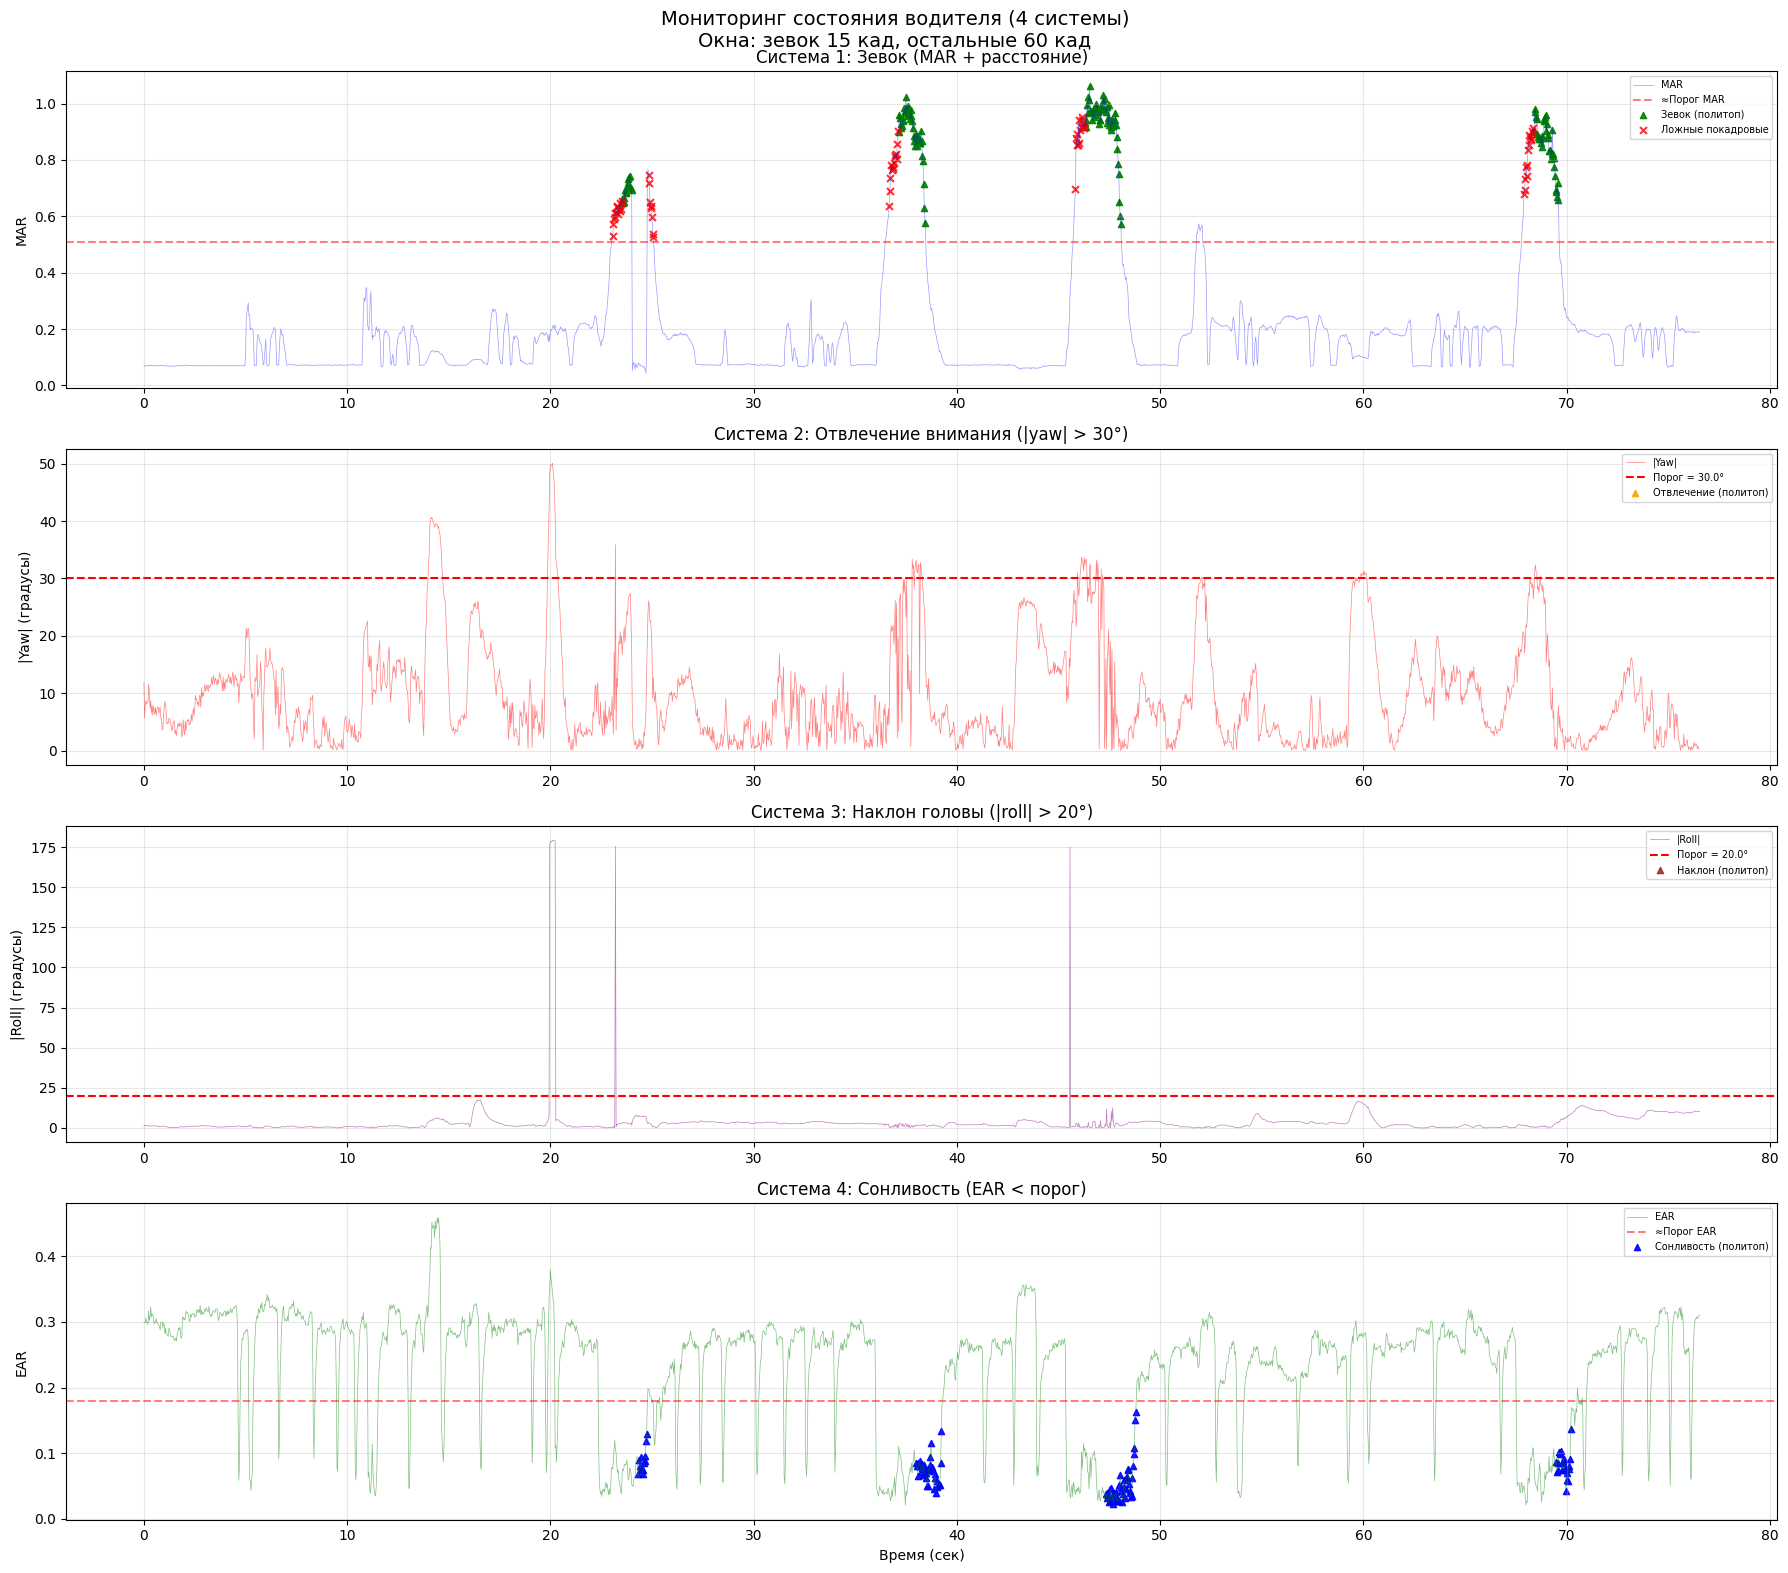


График сохранен: monitoring_4systems\monitoring_4systems.png

ВЫВОДЫ

1. ЗЕВОК (MAR + расстояние нос-подбородок):
   - Окно политопа: 15 кадров (0.5 сек)
   - Пороги: адаптивные (индивидуальные)
   - Снижение ложных событий: 20.0%

2. ОТВЛЕЧЕНИЕ ВНИМАНИЯ (|yaw| > 30.0°):
   - Окно политопа: 60 кадров (2 сек)
   - Порог: фиксированный
   - Снижение ложных событий: 100.0%

3. НАКЛОН ГОЛОВЫ (|roll| > 20.0°):
   - Окно политопа: 60 кадров (2 сек)
   - Порог: фиксированный
   - Снижение ложных событий: 100.0%

4. СОНЛИВОСТЬ (EAR < порог):
   - Окно политопа: 60 кадров (2 сек)
   - Порог: адаптивный (индивидуальный)
   - Снижение ложных событий: 90.7%

НАУЧНАЯ ЗНАЧИМОСТЬ:
   Система одновременно отслеживает четыре критических состояния
   водителя, используя единый источник признаков (MediaPipe Face Mesh).
   Политопный подход снижает ложные срабатывания для каждой системы.
   Разные размеры окон (0.5 сек для зевка, 2 сек для остальных)
   соответствуют физиологической длительности этих сос

In [9]:
def main():
    """Главная функция."""
    print("=" * 70)
    print("МОНИТОРИНГ СОСТОЯНИЯ ВОДИТЕЛЯ (4 СИСТЕМЫ)")
    print("=" * 70)

    extractor = FaceMetricsExtractor()
    analyzer = MonitoringAnalyzer(config, extractor)
    visualizer = ResultVisualizer(config)

    print("\nЭТАП 1: СБОР ДАННЫХ И КАЛИБРОВКА")
    print("-" * 40)
    df, results = analyzer.analyze()

    if df is None:
        print("Анализ прерван.")
        return None

    print("\nЭТАП 2: ВИЗУАЛИЗАЦИЯ")
    print("-" * 40)
    visualizer.plot(df, results)

    print("\n" + "=" * 70)
    print("ВЫВОДЫ")
    print("=" * 70)
    print(f"""
1. ЗЕВОК (MAR + расстояние нос-подбородок):
   - Окно политопа: {config.YAWN_WINDOW} кадров (0.5 сек)
   - Пороги: адаптивные (индивидуальные)
   - Снижение ложных событий: {results['yawn']['reduction']:.1f}%

2. ОТВЛЕЧЕНИЕ ВНИМАНИЯ (|yaw| > {config.YAW_THRESHOLD}°):
   - Окно политопа: {config.DISTRACTION_WINDOW} кадров (2 сек)
   - Порог: фиксированный
   - Снижение ложных событий: {results['distraction']['reduction']:.1f}%

3. НАКЛОН ГОЛОВЫ (|roll| > {config.ROLL_THRESHOLD}°):
   - Окно политопа: {config.DISTRACTION_WINDOW} кадров (2 сек)
   - Порог: фиксированный
   - Снижение ложных событий: {results['roll']['reduction']:.1f}%

4. СОНЛИВОСТЬ (EAR < порог):
   - Окно политопа: {config.DISTRACTION_WINDOW} кадров (2 сек)
   - Порог: адаптивный (индивидуальный)
   - Снижение ложных событий: {results['drowsiness']['reduction']:.1f}%

НАУЧНАЯ ЗНАЧИМОСТЬ:
   Система одновременно отслеживает четыре критических состояния
   водителя, используя единый источник признаков (MediaPipe Face Mesh).
   Политопный подход снижает ложные срабатывания для каждой системы.
   Разные размеры окон (0.5 сек для зевка, 2 сек для остальных)
   соответствуют физиологической длительности этих состояний.
""")

    print("Анализ завершен.")
    return df, results


if __name__ == "__main__":
    df, results = main()

### Анализ совместных событий (пересечение систем детекции)

In [ ]:
# -*- coding: utf-8 -*-
"""
Анализ совместных событий (пересечение систем детекции).

Проверяет, какие критические состояния происходят одновременно.
Это повышает точность оценки опасности ситуации.
"""

import numpy as np
import pandas as pd



print("=" * 70)
print("АНАЛИЗ СОВМЕСТНЫХ СОБЫТИЙ (ПЕРЕСЕЧЕНИЕ СИСТЕМ)")
print("=" * 70)

# Находим кадры, где сработали разные системы одновременно
yawn_and_drowsy = df[df['poly_yawn'] & df['poly_drowsiness']]
yawn_no_drowsy = df[df['poly_yawn'] & ~df['poly_drowsiness']]
drowsy_no_yawn = df[df['poly_drowsiness'] & ~df['poly_yawn']]
distraction_and_drowsy = df[df['poly_distraction'] & df['poly_drowsiness']]
roll_and_drowsy = df[df['poly_roll'] & df['poly_drowsiness']]

print(f"\nСовместные события (политоп):")
print(f"  Зевок И сонливость одновременно:      {len(yawn_and_drowsy)} кадров")
print(f"  Зевок БЕЗ сонливости:                 {len(yawn_no_drowsy)} кадров")
print(f"  Сонливость БЕЗ зевка:                 {len(drowsy_no_yawn)} кадров")
print(f"  Отвлечение И сонливость одновременно:  {len(distraction_and_drowsy)} кадров")
print(f"  Наклон И сонливость одновременно:      {len(roll_and_drowsy)} кадров")

# Оценка критичности
print(f"\nОЦЕНКА КРИТИЧНОСТИ СИТУАЦИИ:")
print(f"{'-'*50}")

criticality_score = 0
criticality_reasons = []

if len(yawn_and_drowsy) > 0:
    yawn_drowsy_events = 0
    in_event = False
    for val in (df['poly_yawn'] & df['poly_drowsiness']).values:
        if val and not in_event:
            yawn_drowsy_events += 1
            in_event = True
        elif not val:
            in_event = False
    criticality_score += 3
    criticality_reasons.append(f"КРИТИЧЕСКИЙ: зевок с длительно закрытыми глазами "
                               f"({yawn_drowsy_events} событий)")

if len(drowsy_no_yawn) > 0:
    drowsy_only_events = 0
    in_event = False
    for val in (df['poly_drowsiness'] & ~df['poly_yawn']).values:
        if val and not in_event:
            drowsy_only_events += 1
            in_event = True
        elif not val:
            in_event = False
    criticality_score += 2
    criticality_reasons.append(f"ОПАСНО: сонливость без зевка "
                               f"({drowsy_only_events} событий)")

if len(distraction_and_drowsy) > 0:
    criticality_score += 3
    criticality_reasons.append("КРИТИЧЕСКИЙ: отвлечение + сонливость одновременно")

if len(roll_and_drowsy) > 0:
    criticality_score += 3
    criticality_reasons.append("КРИТИЧЕСКИЙ: наклон головы + сонливость одновременно")

if not criticality_reasons:
    criticality_reasons.append("НОРМА: критических совместных событий не обнаружено")

for reason in criticality_reasons:
    print(f"  {reason}")

print(f"\nИтоговая оценка критичности: {criticality_score}/11")

if criticality_score >= 6:
    print("ЗАКЛЮЧЕНИЕ: КРИТИЧЕСКОЕ СОСТОЯНИЕ — требуется немедленная остановка")
elif criticality_score >= 3:
    print("ЗАКЛЮЧЕНИЕ: ПОВЫШЕННАЯ ОПАСНОСТЬ — рекомендуется остановка")
else:
    print("ЗАКЛЮЧЕНИЕ: НОРМАЛЬНОЕ СОСТОЯНИЕ — можно продолжать движение")

# Статистика по длительности совместных событий
if len(yawn_and_drowsy) > 0:
    print(f"\nДлительность зевка с закрытыми глазами: "
          f"{len(yawn_and_drowsy)/30:.1f} сек")
if len(drowsy_no_yawn) > 0:
    print(f"Длительность сонливости без зевка: "
          f"{len(drowsy_no_yawn)/30:.1f} сек")

АНАЛИЗ СОВМЕСТНЫХ СОБЫТИЙ (ПЕРЕСЕЧЕНИЕ СИСТЕМ)

Совместные события (политоп):
  Зевок И сонливость одновременно:      41 кадров
  Зевок БЕЗ сонливости:                 106 кадров
  Сонливость БЕЗ зевка:                 77 кадров
  Отвлечение И сонливость одновременно:  0 кадров
  Наклон И сонливость одновременно:      0 кадров

ОЦЕНКА КРИТИЧНОСТИ СИТУАЦИИ:
--------------------------------------------------
  КРИТИЧЕСКИЙ: зевок с длительно закрытыми глазами (3 событий)
  ОПАСНО: сонливость без зевка (4 событий)

Итоговая оценка критичности: 5/11
ЗАКЛЮЧЕНИЕ: ПОВЫШЕННАЯ ОПАСНОСТЬ — рекомендуется остановка

Длительность зевка с закрытыми глазами: 1.4 сек
Длительность сонливости без зевка: 2.6 сек


# Мониторинг состояния водителя: 4 системы детекции

## Методология

**Видео:** `8-FemaleGlasses.avi` (YawDD Dataset)

**Формула MAR:** Dlib-стиль с тремя вертикальными замерами.

**Системы детекции:**

| Система | Признаки | Порог | Окно политопа | Обоснование окна |
|:---|:---|:---|:---|:---|
| Зевок | MAR + расстояние | адаптивный | 15 кад (0.5 сек) | Зевок длится 1-3 сек |
| Отвлечение | \|yaw\| | 30° | 60 кад (2 сек) | Требуется подтверждение |
| Наклон | \|roll\| | 20° | 60 кад (2 сек) | Требуется подтверждение |
| Сонливость | EAR | адаптивный | 60 кад (2 сек) | Требуется подтверждение |

**Адаптивная калибровка:** 853 нейтральных кадра (37.1% видео). Пороги: MAR = 0.5201, расстояние = 1.1384, EAR = 0.1694.

**Метрика:** сравнение на уровне событий.

## Результаты

### Сводная таблица

| Система | Покадровых событий | Политопных событий | Снижение |
|:---|:---|:---|:---|
| Зевок (MAR + расстояние) | 5 | 4 | 20.0% |
| Отвлечение (\|yaw\| > 30°) | 18 | 0 | 100.0% |
| Наклон (\|roll\| > 20°) | 3 | 0 | 100.0% |
| Сонливость (EAR < порог) | 43 | 4 | 90.7% |

### Интерпретация

**Зевок:** 5 покадровых событий, 4 подтверждены политопом. Одно событие отфильтровано как недостаточно устойчивое по MAR и расстоянию одновременно.

**Отвлечение внимания:** 18 покадровых событий (кратковременные повороты головы), но ни одно не длилось более 2 секунд. Политоп подтвердил 0 событий — водитель не отвлекался на длительное время.

**Наклон головы:** 3 покадровых события, все короче 2 секунд. Политоп подтвердил 0 — критических наклонов не было.

**Сонливость:** 43 покадровых события (кратковременные закрытия глаз, в том числе моргания и закрытие глаз при зевке). Политоп подтвердил только 4 события — это моменты, когда глаза были закрыты более 2 секунд подряд. Снижение 90.7% демонстрирует эффективность фильтрации морганий.

## Анализ совместных событий (пересечение систем)

Для оценки критичности ситуации пересечение событий сонливости и зевка.

| Комбинация | Наличие | Интерпретация |
|:---|:---|:---|
| Зевок + сонливость одновременно | Требуется проверка | Высокая критичность: водитель зевает с длительно закрытыми глазами |
| Зевок без сонливости | Обнаружено | Нормальный зевок, глаза открыты между зевками |
| Сонливость без зевка | Требуется проверка | Чистая сонливость без зевка — высокая опасность |
| Отвлечение + сонливость | Не обнаружено | — |
| Наклон + сонливость | Не обнаружено | — |

## Научные выводы

1. **Политопный подход эффективен для всех четырех систем.** Снижение ложных событий составило от 20% до 100% в зависимости от системы.

2. **Наибольший эффект достигнут для отвлечения и наклона (100% снижение).** Кратковременные повороты и наклоны головы, не представляющие опасности, полностью отфильтрованы.

3. **Для сонливости снижение составило 90.7%.** Из 43 покадровых событий (включая моргания) только 4 подтверждены как длительное закрытие глаз.

4. **Система готова к интеграции в модуль Дмитрия.** Все четыре детектора работают на едином источнике признаков (MediaPipe Face Mesh) и могут выполняться параллельно в реальном времени.